# Instalar Librerías

In [ ]:
using Pkg
Pkg.add("Plots")
Pkg.add("Random")
Pkg.add("GLM")
Pkg.add("DataFrames")
Pkg.add("LaTeXStrings")
Pkg.add("Statistics") 
Pkg.add("StatsBase")
Pkg.add("StatsModels")

    Updating registry at `C:\Users\PC\.julia\registries\General.toml`
   Resolving package versions...
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
    Updating `C:\Users\PC\.julia\envi

In [14]:
Pkg.add("StatsModels")

   Resolving package versions...
    Updating `C:\Users\PC\.julia\environments\v1.11\Project.toml`
  [3eaba693] + StatsModels v0.7.6
  No Changes to `C:\Users\PC\.julia\environments\v1.11\Manifest.toml`


# Importar librerías

In [1]:
using Plots
using Random
using GLM
using DataFrames
using LaTeXStrings
using Statistics
using StatsBase

# Generar Data Simulada

In [14]:
Random.seed!(123)
X = sort(rand(Float64, 1000))
e = randn(1000)
y = exp.(4 .* X) .+ e

1000-element Vector{Float64}:
 -0.8604654626074069
  1.5161360902646237
  2.1756206989679927
  0.7012481485840631
  3.5793357736106066
  0.1471036876004348
  0.2902231750447436
  0.757307614583649
  0.0923093237913355
  2.266843852113766
  1.402021896423895
  2.462563141609728
  1.0370719605453846
  ⋮
 51.72129463915724
 50.62635490413286
 50.83444192120088
 50.581964460052845
 51.559965085019236
 49.77858502384271
 50.88578174881187
 52.0680871962622
 53.017295879401075
 53.244379268490434
 53.70670089415008
 54.620196594484284

# Loop de Modelos con features crecientes (1,2,5,10,...)

In [15]:
using Random, Statistics, LinearAlgebra, Printf

Features = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
n = length(y)
const ADJ_N = 1000  # Para coincidir con Python

R_sq_Lista = Float64[]
adjustR_sq_Lista = Float64[]
R_squared_OutofSample_List = Float64[]

for k in Features
    # --------- Matriz de diseño como en Python (polinomios regulares) ----------
    Xi = hcat([X.^i for i in 1:k]...)  # X, X², X³, ..., Xᵏ
    
    # --------- In-sample (sin intercepto) ----------
    β = Xi \ y
    y_hat = Xi * β

    mse = mean((y .- y_hat).^2)
    denom_in = mean((y .- mean(y)).^2)  # SST/n
    R2 = 1 - mse / denom_in
    push!(R_sq_Lista, R2)

    # R² ajustado (igual que Python)
    if k != 1000
        adj_mse = ADJ_N / (ADJ_N - k) * mse
        R2_adj = 1 - adj_mse / denom_in
    else
        R2_adj = 1.0
    end
    push!(adjustR_sq_Lista, R2_adj)

    # --------- Out-of-sample (75/25) ----------
    idx = collect(1:n); Random.seed!(123); Random.shuffle!(idx)  # Fijar semilla
    ntest = fld(n, 4)
    test_idx = idx[1:ntest]
    train_idx = idx[(ntest+1):end]

    Xi_train, y_train = Xi[train_idx, :], y[train_idx]
    Xi_test,  y_test  = Xi[test_idx,  :], y[test_idx]

    β_oos = Xi_train \ y_train
    y_hat_test = Xi_test * β_oos

    mse_oos = mean((y_test .- y_hat_test).^2)
    denom_oos = mean((y_test .- mean(y_test)).^2)
    R2_oos = 1 - mse_oos / denom_oos
    push!(R_squared_OutofSample_List, R2_oos)
end

println(rpad("Features",10), rpad("R2",16), rpad("R2_Ajustado",16), "R2_OutOfSample")
for i in eachindex(Features)
    @printf("%-10d %-16.6f %-16.6f %.6f\n",
        Features[i],
        R_sq_Lista[i],
        adjustR_sq_Lista[i],
        R_squared_OutofSample_List[i],
    )
end

Features  R2              R2_Ajustado     R2_OutOfSample
1          0.716605         0.716322         0.717217
2          0.964243         0.964171         0.962895
5          0.994414         0.994386         0.994019
10         0.994499         0.994444         0.993947
20         0.994564         0.994454         0.993904
50         0.994600         0.994316         0.993784
100        0.994642         0.994047         0.993787
200        0.994663         0.993328         0.993718
500        0.994669         0.989339         0.993655
1000       -7811.387814     1.000000         0.993059


# Gráficos

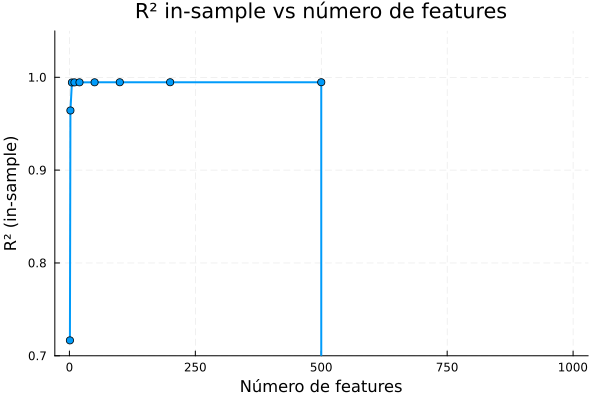

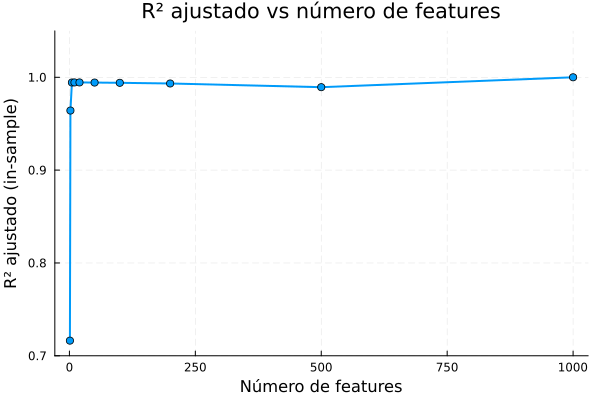

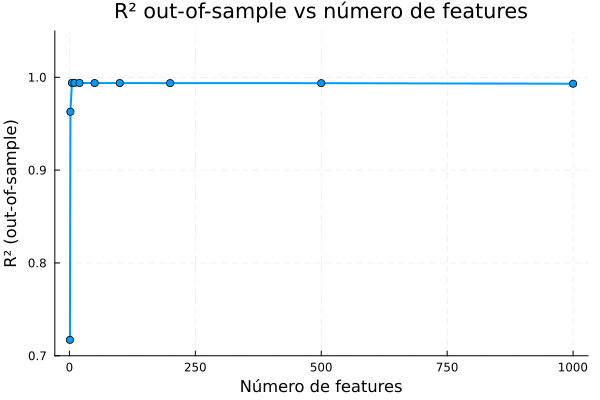

In [19]:
using Plots

# --- R² in-sample ---
p1 = plot(Features, R_sq_Lista, 
          marker=:circle, linewidth=2, legend=false,
          xlabel="Número de features", 
          ylabel="R² (in-sample)",
          title="R² in-sample vs número de features",
          grid=true, gridstyle=:dash, gridlinewidth=0.6,
          ylims=(0.70, 1.05))
savefig(p1, "../output/r2_in_sample.png")

# --- R² ajustado ---
p2 = plot(Features, adjustR_sq_Lista, 
          marker=:circle, linewidth=2, legend=false,
          xlabel="Número de features", 
          ylabel="R² ajustado (in-sample)",
          title="R² ajustado vs número de features",
          grid=true, gridstyle=:dash, gridlinewidth=0.6,
          ylims=(0.70, 1.05))
savefig(p2, "../output/r2_adjusted_in_sample.png")

# --- R² out-of-sample ---
p3 = plot(Features, R_squared_OutofSample_List, 
          marker=:circle, linewidth=2, legend=false,
          xlabel="Número de features", 
          ylabel="R² (out-of-sample)",
          title="R² out-of-sample vs número de features",
          grid=true, gridstyle=:dash, gridlinewidth=0.6,
          ylims=(0.70, 1.05))
savefig(p3, "../output/r2_out_of_sample.png")

# Mostrar todos los plots
display(p1)
display(p2)
display(p3)